# EDA: Прогнозирование отгрузок со складов маркетплейса

## Содержание
1. [Загрузка и обзор данных](#1)
2. [Структура train / test](#2)
3. [Распределение целевой переменной](#3)
4. [Масштаб маршрутов](#4)
5. [Временные паттерны (час, день недели)](#5)
6. [Автокорреляция таргета](#6)
7. [Status-фичи: распределение и корреляции](#7)
8. [Лаговые корреляции status → target](#8)
9. [Паттерны по дням: тепловые карты](#9)
10. [Бейзлайны](#10)
11. [Выводы](#11)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

train = pd.read_parquet('Data/train_solo_track.parquet')
test = pd.read_parquet('Data/test_solo_track.parquet')
print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (4630000, 9)
Test shape:  (8000, 3)


<a id="1"></a>
## 1. Загрузка и обзор данных

In [2]:
print('=== TRAIN ===')
print(f'Columns: {list(train.columns)}')
print(f'Dtypes:\n{train.dtypes}\n')
display(train.head(10))
print(f'\n=== Описательная статистика ===')
display(train.describe())
print(f'\nПропуски:\n{train.isnull().sum()}')

=== TRAIN ===
Columns: ['route_id', 'timestamp', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'target_1h']
Dtypes:
route_id              int64
timestamp    datetime64[ns]
status_1              int64
status_2              int64
status_3              int64
status_4              int64
status_5              int64
status_6              int64
target_1h             int64
dtype: object



,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,471,2025-07-28 00:00:00,13,23,45,85645,491354,487,88655
1,471,2025-07-28 00:30:00,14,18,1,80049,494754,489,223929
2,471,2025-07-28 01:00:00,8,8,38,82616,490659,487,168519
3,471,2025-07-28 01:30:00,10,2,7,80506,489967,494,111380
4,471,2025-07-28 02:00:00,7,5,13,85992,479743,494,246046
5,471,2025-07-28 02:30:00,13,13,9,84988,484448,484,279432
6,471,2025-07-28 03:00:00,16,18,2,85730,484198,469,144766
7,471,2025-07-28 03:30:00,8,16,1,78109,490481,496,0
8,471,2025-07-28 04:00:00,10,11,22,81731,484597,480,5331
9,471,2025-07-28 04:30:00,12,14,36,83616,491429,488,95108



=== Описательная статистика ===


,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
count,4.630000e+06,4630000,4.630000e+06,4.630000e+06,4.630000e+06,4.630000e+06,4.630000e+06,4.630000e+06,4.630000e+06
mean,4.995000e+02,2025-09-14 05:14:59.999999488,2.267677e+01,2.285854e+01,2.285684e+01,1.192156e+05,7.019789e+05,3.344607e+03,2.612421e+05
min,0.000000e+00,2025-07-28 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.390000e+03,1.851900e+04,0.000000e+00,0.000000e+00
25%,2.497500e+02,2025-08-21 02:30:00,1.300000e+01,1.300000e+01,8.000000e+00,7.496700e+04,3.897790e+05,4.600000e+01,1.389900e+05
50%,4.995000e+02,2025-09-14 05:15:00,2.100000e+01,2.100000e+01,1.900000e+01,1.099120e+05,6.188360e+05,1.620000e+02,2.357690e+05
75%,7.492500e+02,2025-10-08 08:00:00,3.000000e+01,3.000000e+01,3.300000e+01,1.523090e+05,9.155220e+05,1.243000e+03,3.551750e+05
max,9.990000e+02,2025-11-01 10:30:00,8.020000e+02,5.220000e+02,6.200000e+02,5.879380e+05,3.503114e+06,1.527390e+05,1.083134e+07
std,2.886750e+02,NaN,1.304141e+01,1.285778e+01,1.943999e+01,5.982565e+04,4.213063e+05,1.004817e+04,1.690826e+05



Пропуски:
route_id     0
timestamp    0
status_1     0
status_2     0
status_3     0
status_4     0
status_5     0
status_6     0
target_1h    0
dtype: int64


In [3]:
print('=== TEST ===')
print(f'Columns: {list(test.columns)}')
display(test.head(10))
print(f'\nПропуски:\n{test.isnull().sum()}')

=== TEST ===
Columns: ['id', 'route_id', 'timestamp']


,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00
5,5,471,2025-11-01 13:30:00
6,6,471,2025-11-01 14:00:00
7,7,471,2025-11-01 14:30:00
8,8,496,2025-11-01 11:00:00
9,9,496,2025-11-01 11:30:00



Пропуски:
id           0
route_id     0
timestamp    0
dtype: int64


<a id="2"></a>
## 2. Структура train / test

Ключевые вопросы: временной диапазон, гранулярность, связь train↔test.

In [4]:
print(f'Train period:  {train.timestamp.min()} → {train.timestamp.max()}')
print(f'Test period:   {test.timestamp.min()} → {test.timestamp.max()}')
print(f'Train duration: {train.timestamp.max() - train.timestamp.min()} (~96.5 дней)')
print(f'Test duration:  {test.timestamp.max() - test.timestamp.min()} (4 часа)')
print(f'Gap train→test: {test.timestamp.min() - train.timestamp.max()} (один шаг)')
print(f'\nТест — это суббота (dow={test.timestamp.iloc[0].dayofweek})')
print(f'\nМаршрутов в train: {train.route_id.nunique()}')
print(f'Маршрутов в test:  {test.route_id.nunique()}')
print(f'Все маршруты test есть в train: {set(test.route_id.unique()).issubset(set(train.route_id.unique()))}')
print(f'Timestamps per route (train): {train.groupby("route_id")["timestamp"].nunique().unique()}  (идеальная сетка)')
print(f'Timestamps per route (test):  {test.groupby("route_id")["timestamp"].nunique().unique()}')
print(f'\nTest timestamps: {sorted(test.timestamp.unique())}')

Train period:  2025-07-28 00:00:00 → 2025-11-01 10:30:00
Test period:   2025-11-01 11:00:00 → 2025-11-01 14:30:00
Train duration: 96 days 10:30:00 (~96.5 дней)
Test duration:  0 days 03:30:00 (4 часа)
Gap train→test: 0 days 00:30:00 (один шаг)

Тест — это суббота (dow=5)

Маршрутов в train: 1000
Маршрутов в test:  1000
Все маршруты test есть в train: True


Timestamps per route (train): [4630]  (идеальная сетка)

Timestamps per route (test):  [8]

Test timestamps: [Timestamp('2025-11-01 11:00:00'), Timestamp('2025-11-01 11:30:00'), Timestamp('2025-11-01 12:00:00'), Timestamp('2025-11-01 12:30:00'), Timestamp('2025-11-01 13:00:00'), Timestamp('2025-11-01 13:30:00'), Timestamp('2025-11-01 14:00:00'), Timestamp('2025-11-01 14:30:00')]


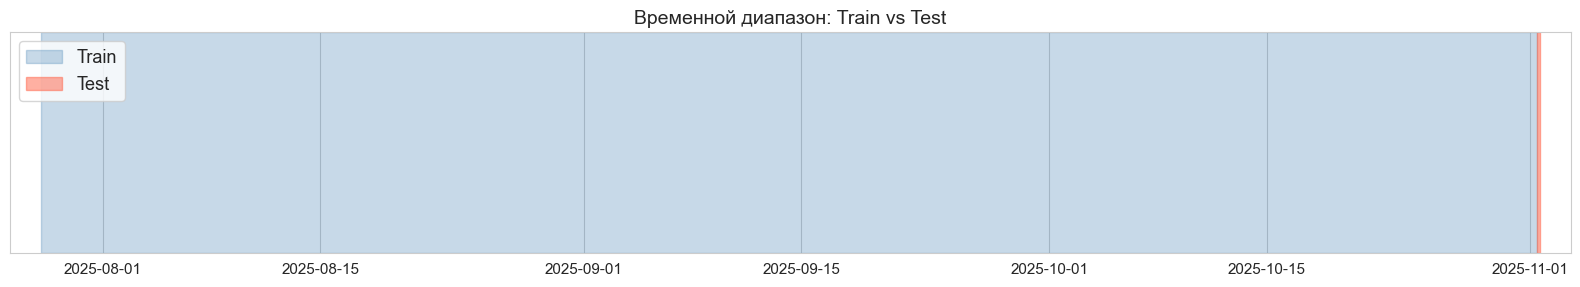

In [5]:
# Визуализация: timeline train vs test
fig, ax = plt.subplots(figsize=(16, 3))
ax.axvspan(train.timestamp.min(), train.timestamp.max(), alpha=0.3, color='steelblue', label='Train')
ax.axvspan(test.timestamp.min(), test.timestamp.max(), alpha=0.5, color='tomato', label='Test')
ax.set_xlim(train.timestamp.min() - pd.Timedelta(days=2), test.timestamp.max() + pd.Timedelta(days=2))
ax.set_yticks([])
ax.legend(fontsize=13, loc='upper left')
ax.set_title('Временной диапазон: Train vs Test', fontsize=14)
plt.tight_layout()
plt.show()

<a id="3"></a>
## 3. Распределение целевой переменной (target_1h)

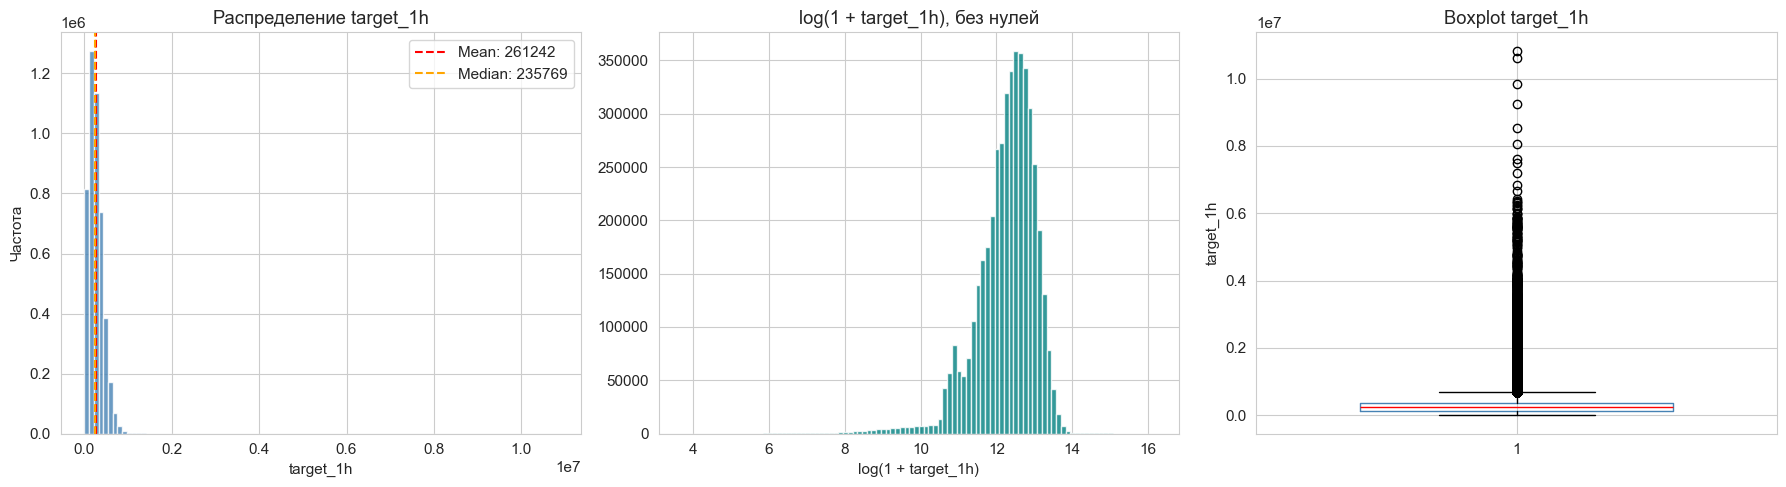

Zeros: 69841 (1.51%)
Skewness: 2.28
Kurtosis: 43.06


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(train['target_1h'], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Распределение target_1h')
axes[0].set_xlabel('target_1h')
axes[0].set_ylabel('Частота')
axes[0].axvline(train['target_1h'].mean(), color='red', ls='--', label=f'Mean: {train["target_1h"].mean():.0f}')
axes[0].axvline(train['target_1h'].median(), color='orange', ls='--', label=f'Median: {train["target_1h"].median():.0f}')
axes[0].legend()

# Log-scale histogram
nonzero = train.loc[train['target_1h'] > 0, 'target_1h']
axes[1].hist(np.log1p(nonzero), bins=100, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('log(1 + target_1h), без нулей')
axes[1].set_xlabel('log(1 + target_1h)')

# Boxplot
axes[2].boxplot(train['target_1h'], vert=True, widths=0.6,
                boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[2].set_title('Boxplot target_1h')
axes[2].set_ylabel('target_1h')

plt.tight_layout()
plt.show()

print(f'Zeros: {(train.target_1h == 0).sum()} ({(train.target_1h == 0).mean()*100:.2f}%)')
print(f'Skewness: {train.target_1h.skew():.2f}')
print(f'Kurtosis: {train.target_1h.kurtosis():.2f}')

In [7]:
# Квантили
print('Квантили target_1h:')
for q in [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f'  {q*100:5.1f}%: {train.target_1h.quantile(q):>12,.0f}')

Квантили target_1h:
    1.0%:            0
    5.0%:       44,889
   10.0%:       70,221
   25.0%:      138,990
   50.0%:      235,769


   75.0%:      355,175
   90.0%:      480,612


   95.0%:      564,384
   99.0%:      743,427


<a id="4"></a>
## 4. Масштаб маршрутов

Маршруты сильно различаются по среднему объёму отгрузок (от 50K до 981K). Это важно для нормализации и feature engineering.

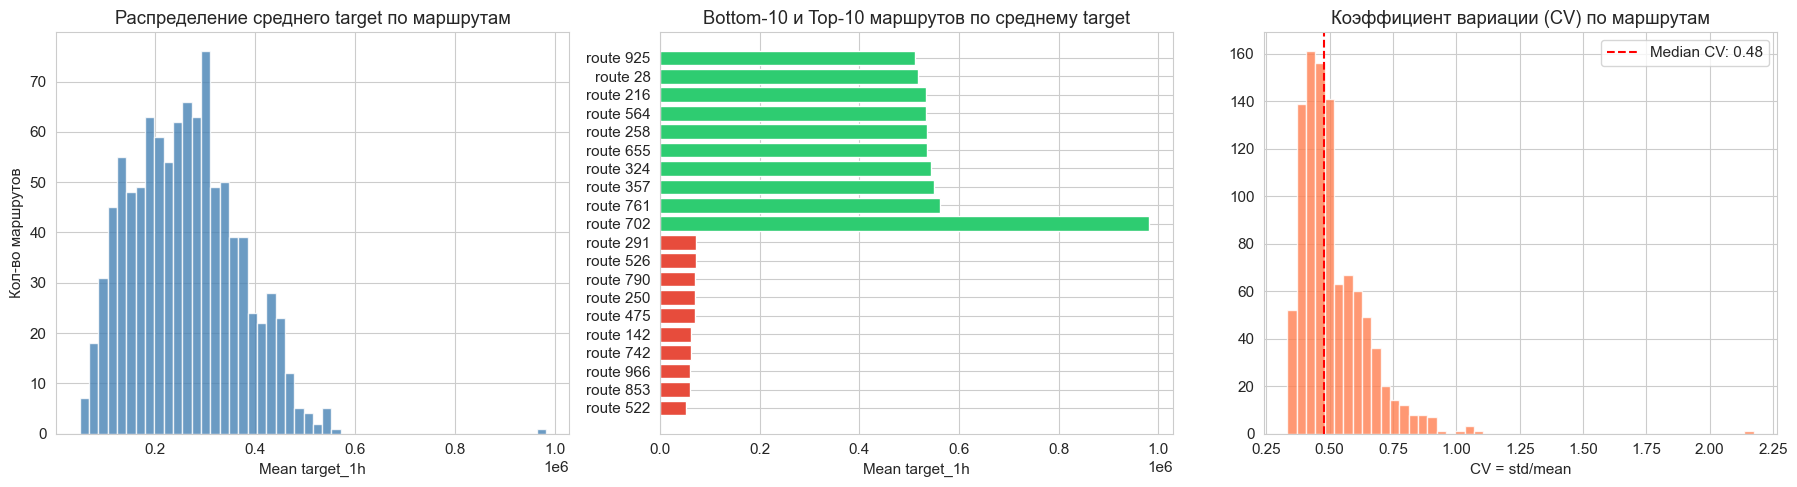

Route mean target: min=50752, max=981152, ratio=19.3x
CV across routes: 0.41


In [8]:
route_stats = train.groupby('route_id')['target_1h'].agg(['mean', 'median', 'std']).reset_index()
route_stats['cv'] = route_stats['std'] / route_stats['mean']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of route means
axes[0].hist(route_stats['mean'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Распределение среднего target по маршрутам')
axes[0].set_xlabel('Mean target_1h')
axes[0].set_ylabel('Кол-во маршрутов')

# Top / bottom routes
top10 = route_stats.nlargest(10, 'mean')
bot10 = route_stats.nsmallest(10, 'mean')
combined = pd.concat([bot10, top10])
colors = ['#e74c3c'] * 10 + ['#2ecc71'] * 10
axes[1].barh(range(20), combined['mean'], color=colors, edgecolor='white')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'route {r}' for r in combined['route_id']])
axes[1].set_title('Bottom-10 и Top-10 маршрутов по среднему target')
axes[1].set_xlabel('Mean target_1h')

# CV distribution
axes[2].hist(route_stats['cv'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[2].set_title('Коэффициент вариации (CV) по маршрутам')
axes[2].set_xlabel('CV = std/mean')
axes[2].axvline(route_stats['cv'].median(), color='red', ls='--', label=f'Median CV: {route_stats["cv"].median():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Route mean target: min={route_stats["mean"].min():.0f}, max={route_stats["mean"].max():.0f}, '
      f'ratio={route_stats["mean"].max()/route_stats["mean"].min():.1f}x')
print(f'CV across routes: {route_stats["mean"].std()/route_stats["mean"].mean():.2f}')

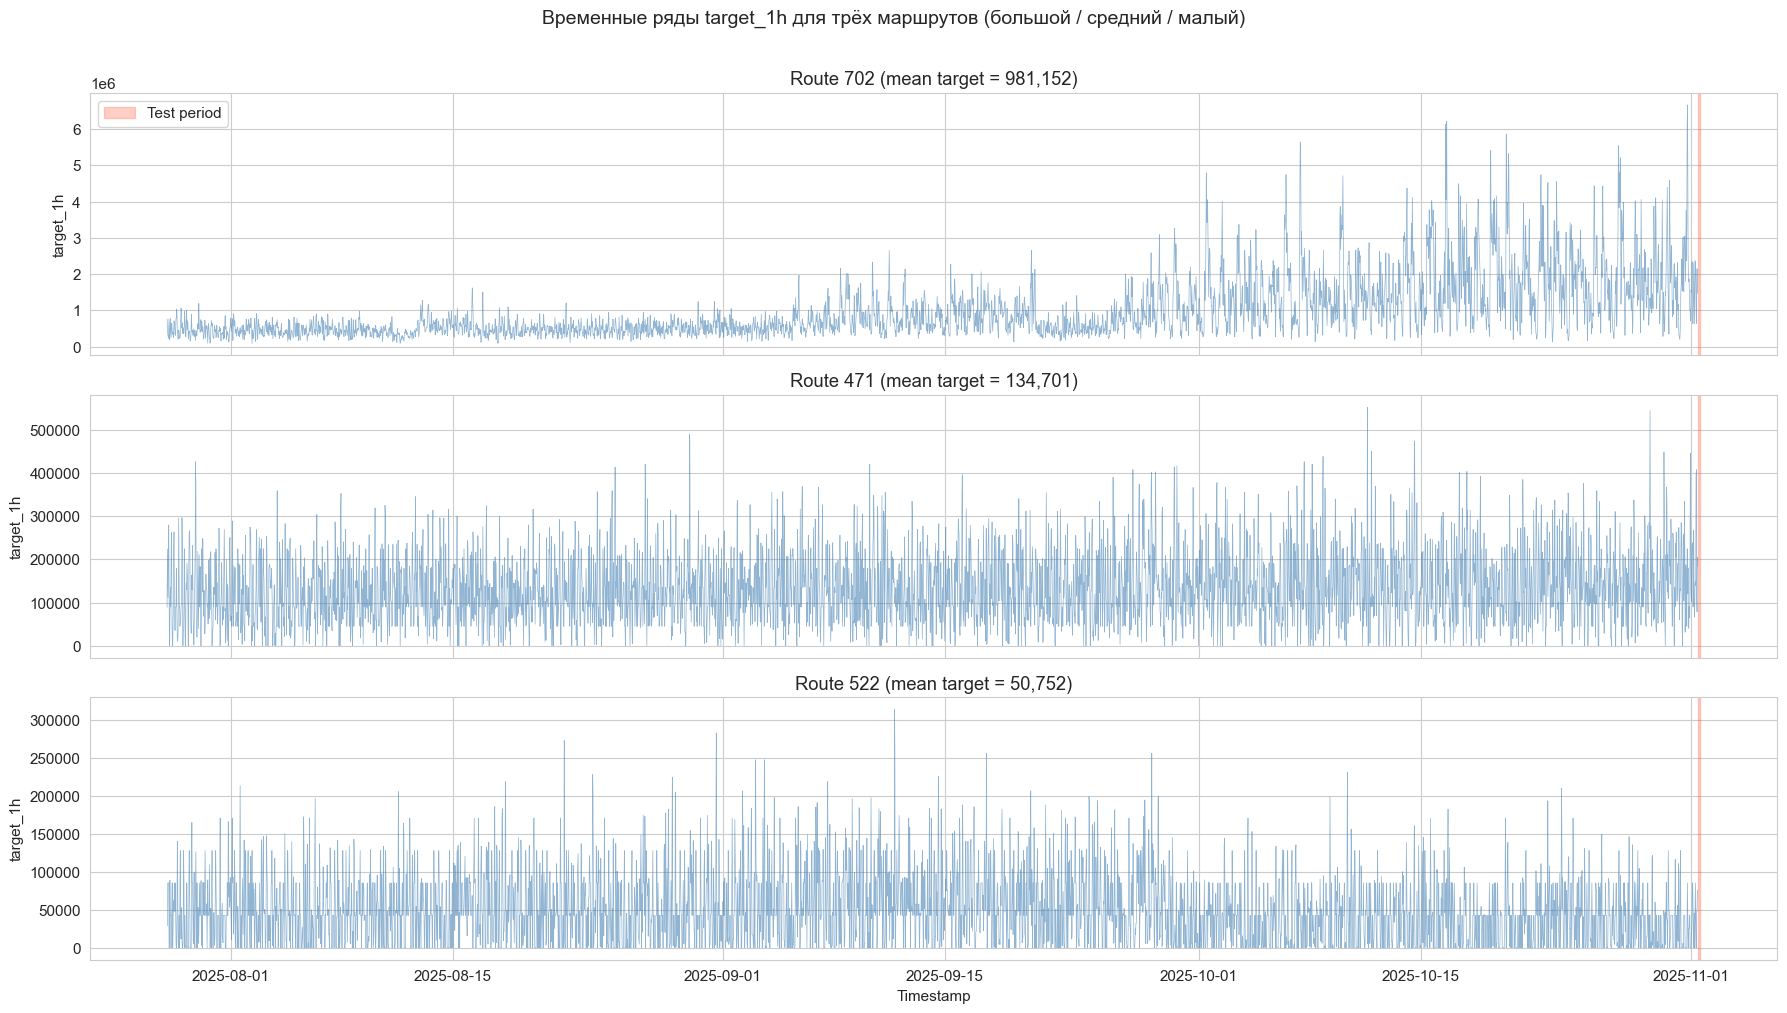

In [9]:
# Временные ряды для нескольких контрастных маршрутов
sample_routes = [702, 471, 522]  # big, medium, small
fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

for i, rid in enumerate(sample_routes):
    r = train[train.route_id == rid].sort_values('timestamp')
    axes[i].plot(r['timestamp'], r['target_1h'], alpha=0.6, linewidth=0.5, color='steelblue')
    axes[i].set_title(f'Route {rid} (mean target = {r["target_1h"].mean():,.0f})')
    axes[i].set_ylabel('target_1h')
    # Mark test period
    axes[i].axvspan(test.timestamp.min(), test.timestamp.max(), alpha=0.3, color='tomato', label='Test period')
    if i == 0:
        axes[i].legend()

axes[-1].set_xlabel('Timestamp')
plt.suptitle('Временные ряды target_1h для трёх маршрутов (большой / средний / малый)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Временные паттерны

Внутридневная (по часам) и недельная (по дням) сезонность.

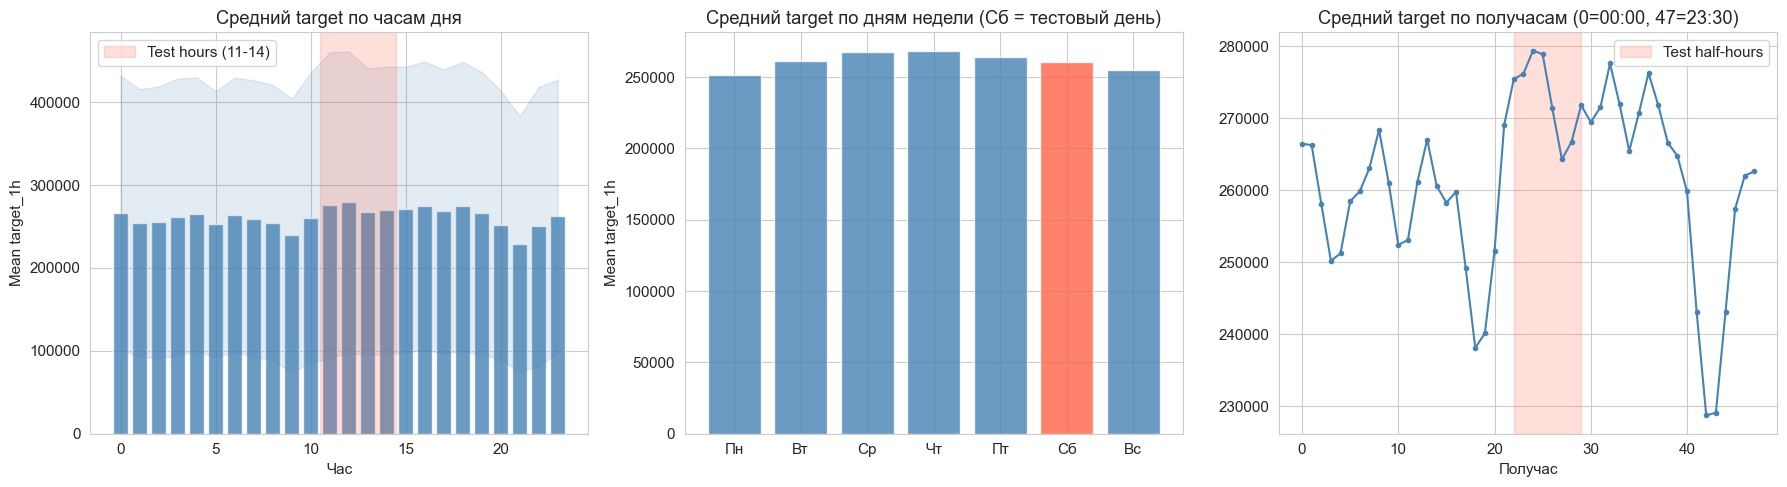

Доля дисперсии, объясняемая часом: 0.4792%
Доля дисперсии, объясняемая днём недели: 0.1315%
→ Сезонность ОЧЕНЬ слабая — основная вариация внутри (route, time) группы


In [10]:
train['hour'] = train.timestamp.dt.hour
train['dow'] = train.timestamp.dt.dayofweek
train['half_hour'] = train.timestamp.dt.hour * 2 + train.timestamp.dt.minute // 30

dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly pattern
hourly = train.groupby('hour')['target_1h'].agg(['mean', 'std'])
axes[0].bar(hourly.index, hourly['mean'], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].fill_between(hourly.index, hourly['mean'] - hourly['std'], hourly['mean'] + hourly['std'],
                     alpha=0.15, color='steelblue')
# Highlight test hours
axes[0].axvspan(10.5, 14.5, alpha=0.2, color='tomato', label='Test hours (11-14)')
axes[0].set_title('Средний target по часам дня')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('Mean target_1h')
axes[0].legend()

# Day of week pattern
dow_agg = train.groupby('dow')['target_1h'].agg(['mean', 'std'])
colors_dow = ['steelblue'] * 5 + ['tomato'] + ['steelblue']
axes[1].bar(range(7), dow_agg['mean'], color=colors_dow, alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_names)
axes[1].set_title('Средний target по дням недели (Сб = тестовый день)')
axes[1].set_ylabel('Mean target_1h')

# Half-hour pattern
hh = train.groupby('half_hour')['target_1h'].mean()
axes[2].plot(hh.index, hh.values, 'o-', color='steelblue', markersize=3)
axes[2].set_title('Средний target по получасам (0=00:00, 47=23:30)')
axes[2].set_xlabel('Получас')
# Mark test half-hours (22-29 → 11:00-14:30)
axes[2].axvspan(22, 29, alpha=0.2, color='tomato', label='Test half-hours')
axes[2].legend()

plt.tight_layout()
plt.show()

# Quantify seasonality strength
total_var = train['target_1h'].var()
hourly_var = train.groupby('hour')['target_1h'].mean().var()
dow_var = train.groupby('dow')['target_1h'].mean().var()
print(f'Доля дисперсии, объясняемая часом: {hourly_var / total_var * 100:.4f}%')
print(f'Доля дисперсии, объясняемая днём недели: {dow_var / total_var * 100:.4f}%')
print('→ Сезонность ОЧЕНЬ слабая — основная вариация внутри (route, time) группы')

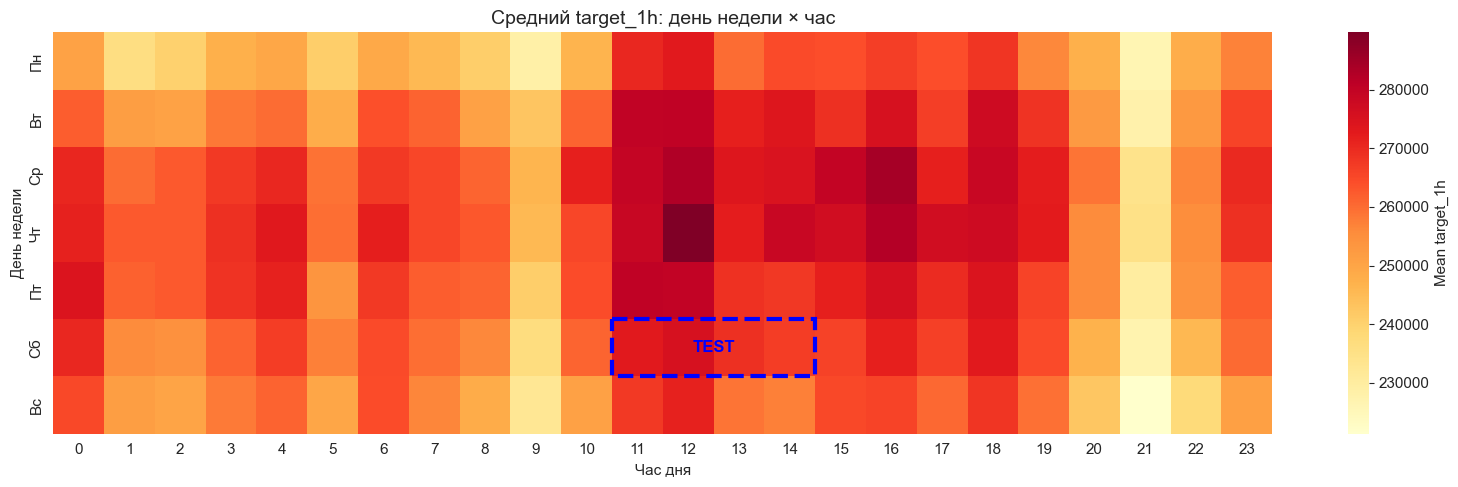

In [11]:
# Внутридневной паттерн по дням недели — heatmap
pivot = train.groupby(['dow', 'hour'])['target_1h'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f', ax=ax,
            yticklabels=dow_names, cbar_kws={'label': 'Mean target_1h'})
ax.set_title('Средний target_1h: день недели × час', fontsize=14)
ax.set_xlabel('Час дня')
ax.set_ylabel('День недели')
# Highlight test area (Saturday 11-14)
from matplotlib.patches import Rectangle
rect = Rectangle((11, 5), 4, 1, linewidth=3, edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(13, 5.5, 'TEST', ha='center', va='center', fontsize=12, fontweight='bold', color='blue')
plt.tight_layout()
plt.show()

<a id="6"></a>
## 6. Автокорреляция таргета

ACF показывает, насколько предыдущие значения предсказывают будущие. Это критично для выбора лагов.

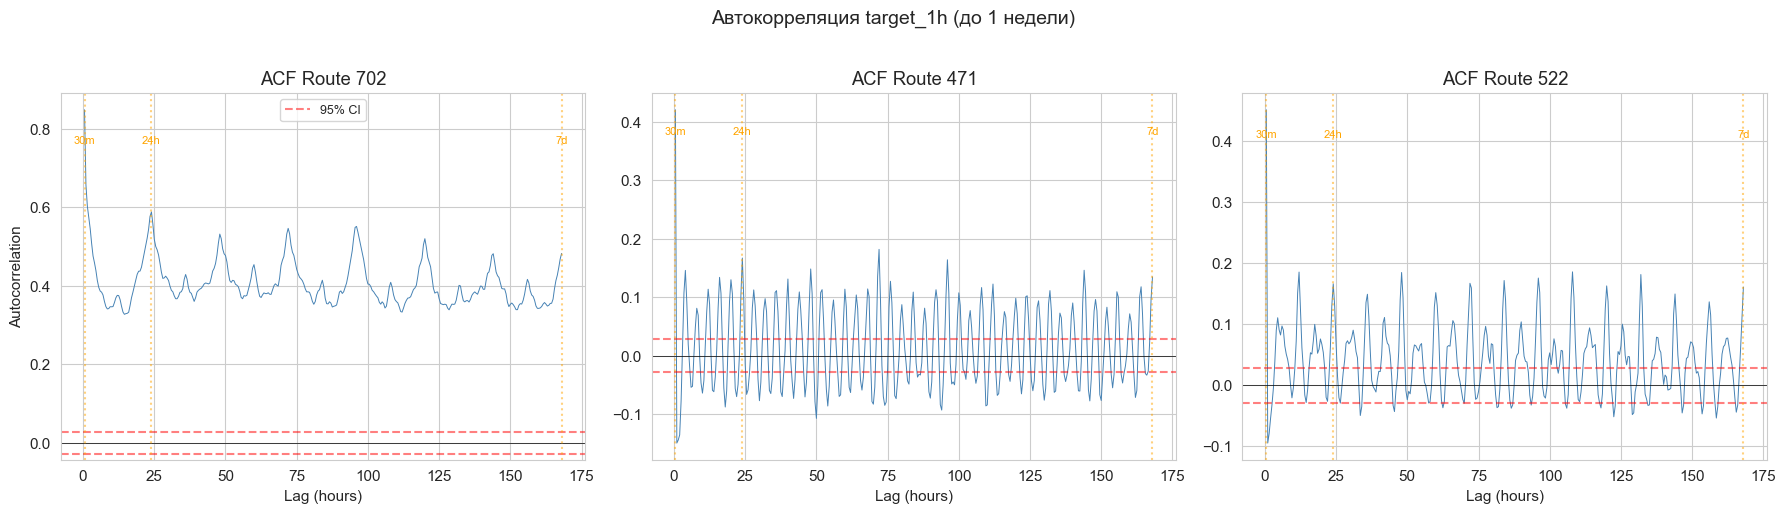

In [12]:
# Autocorrelation for several routes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample_routes_acf = [702, 471, 522]

for i, rid in enumerate(sample_routes_acf):
    r = train[train.route_id == rid].sort_values('timestamp').reset_index(drop=True)
    max_lag = 336  # 1 week
    acf_vals = [r['target_1h'].autocorr(lag=l) for l in range(1, max_lag + 1)]
    lags_hours = np.arange(1, max_lag + 1) * 0.5

    axes[i].plot(lags_hours, acf_vals, linewidth=0.7, color='steelblue')
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].axhline(1.96/np.sqrt(len(r)), color='red', ls='--', alpha=0.5, label='95% CI')
    axes[i].axhline(-1.96/np.sqrt(len(r)), color='red', ls='--', alpha=0.5)

    # Mark key lags
    for lag_h, label in [(0.5, '30m'), (24, '24h'), (168, '7d')]:
        axes[i].axvline(lag_h, color='orange', ls=':', alpha=0.5)
        axes[i].text(lag_h, max(acf_vals) * 0.9, label, ha='center', fontsize=8, color='orange')

    axes[i].set_title(f'ACF Route {rid}')
    axes[i].set_xlabel('Lag (hours)')
    if i == 0:
        axes[i].set_ylabel('Autocorrelation')
        axes[i].legend(fontsize=9)

plt.suptitle('Автокорреляция target_1h (до 1 недели)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

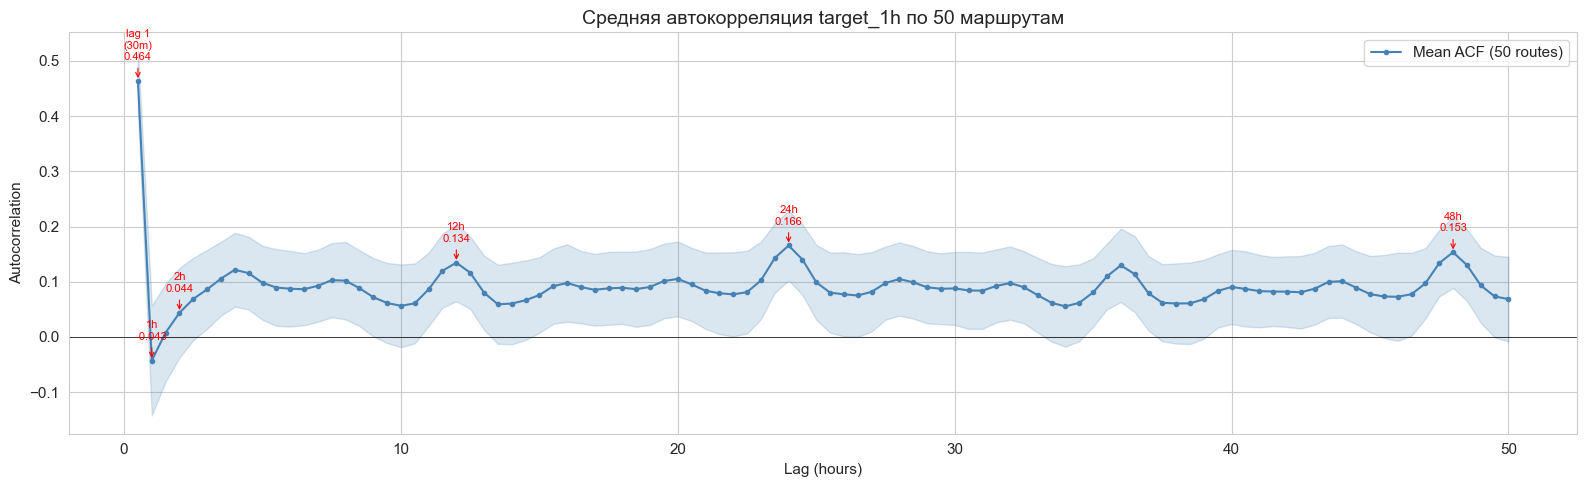

ACF lag-1 (30min): 0.4636 — сильнейший сигнал
ACF lag-2 (1h): -0.0429 — быстрое падение, часто отрицательная
ACF lag-48 (24h): 0.1656 — слабый суточный цикл


In [13]:
# Average ACF across many routes (more robust)
n_sample = 50
np.random.seed(42)
sampled_routes = np.random.choice(train.route_id.unique(), n_sample, replace=False)
max_lag = 100
all_acf = np.zeros((n_sample, max_lag))

for i, rid in enumerate(sampled_routes):
    r = train[train.route_id == rid].sort_values('timestamp').reset_index(drop=True)
    for l in range(max_lag):
        all_acf[i, l] = r['target_1h'].autocorr(lag=l+1)

mean_acf = np.nanmean(all_acf, axis=0)
std_acf = np.nanstd(all_acf, axis=0)
lags_h = (np.arange(max_lag) + 1) * 0.5

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(lags_h, mean_acf, 'o-', markersize=3, color='steelblue', label='Mean ACF (50 routes)')
ax.fill_between(lags_h, mean_acf - std_acf, mean_acf + std_acf, alpha=0.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5)

# Annotations
key_lags = {0.5: 'lag 1\n(30m)', 1: '1h', 2: '2h', 12: '12h', 24: '24h', 48: '48h'}
for lag_h, label in key_lags.items():
    idx = int(lag_h / 0.5) - 1
    if idx < max_lag:
        ax.annotate(f'{label}\n{mean_acf[idx]:.3f}', xy=(lag_h, mean_acf[idx]),
                   xytext=(0, 15), textcoords='offset points', ha='center', fontsize=8,
                   arrowprops=dict(arrowstyle='->', color='red', lw=0.8), color='red')

ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Средняя автокорреляция target_1h по 50 маршрутам', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

print(f'ACF lag-1 (30min): {mean_acf[0]:.4f} — сильнейший сигнал')
print(f'ACF lag-2 (1h): {mean_acf[1]:.4f} — быстрое падение, часто отрицательная')
print(f'ACF lag-48 (24h): {mean_acf[47]:.4f} — слабый суточный цикл')

<a id="7"></a>
## 7. Status-фичи: распределение и корреляции

**ВАЖНО**: status_1–6 отсутствуют в test! Их можно использовать только через лаговые агрегаты из train.

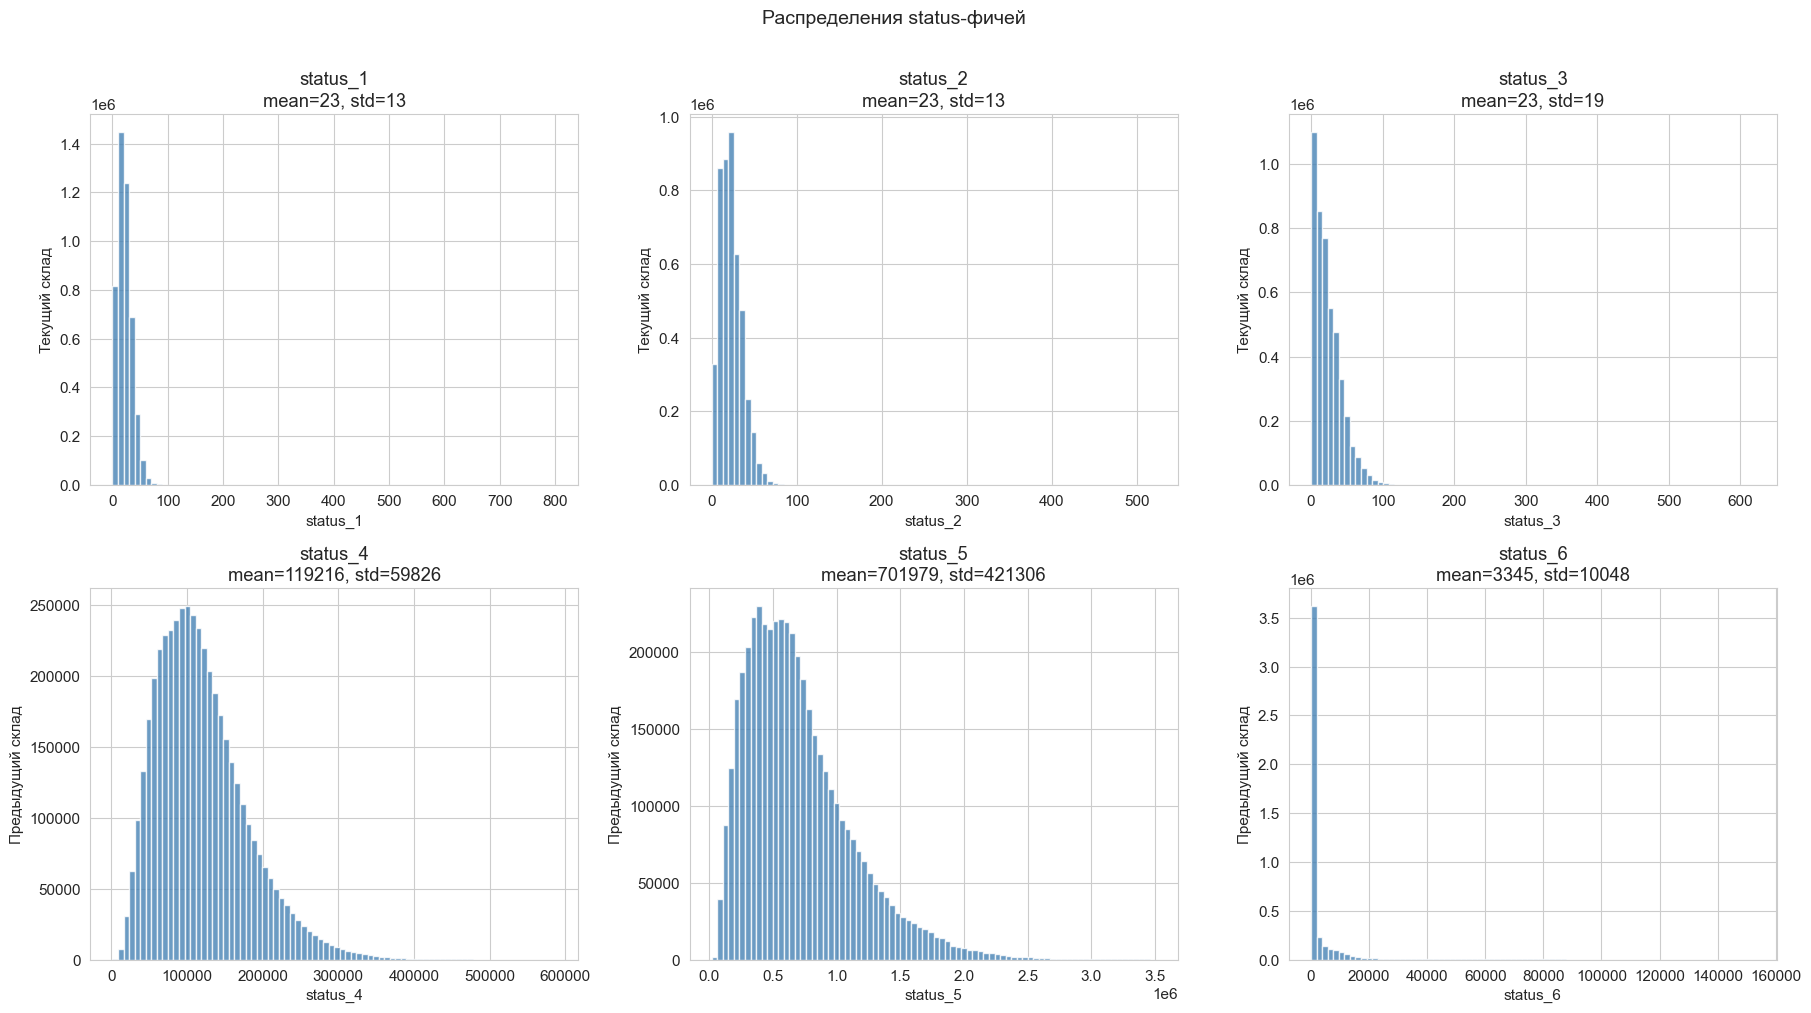

Масштабы фичей (mean):
  status_1:           23
  status_2:           23
  status_3:           23
  status_4:      119,216
  status_5:      701,979
  status_6:        3,345


In [14]:
status_cols = ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(status_cols):
    ax = axes[i // 3, i % 3]
    data = train[col]
    ax.hist(data, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\nmean={data.mean():.0f}, std={data.std():.0f}')
    ax.set_xlabel(col)
    if i < 3:
        ax.set_ylabel('Текущий склад')
    else:
        ax.set_ylabel('Предыдущий склад')

plt.suptitle('Распределения status-фичей', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Масштабы фичей (mean):')
for col in status_cols:
    print(f'  {col}: {train[col].mean():>12,.0f}')

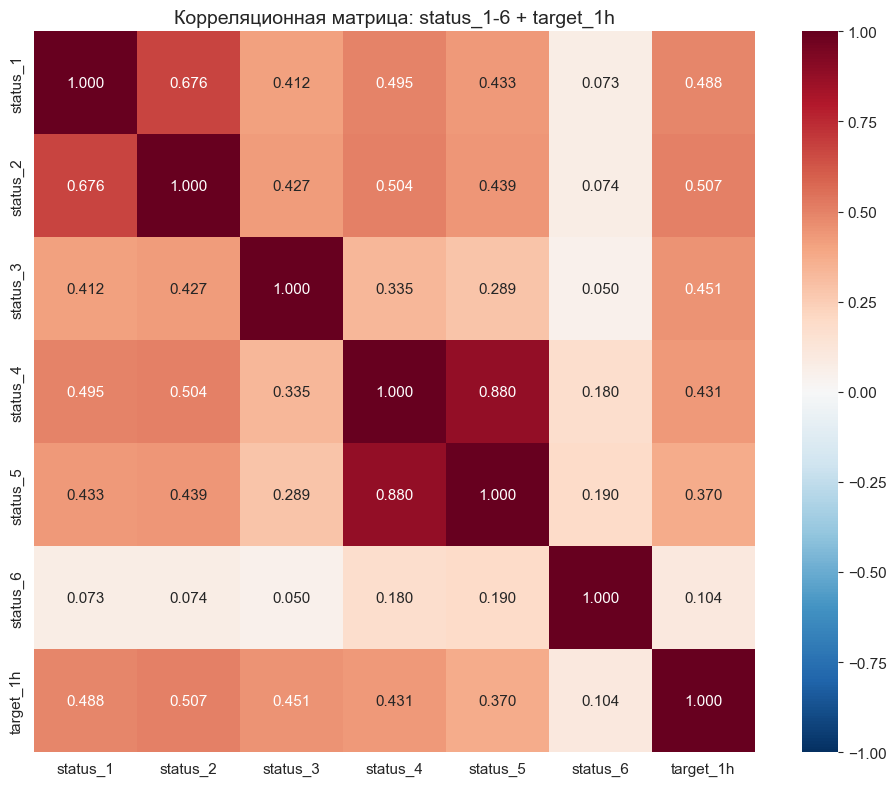


Корреляции с target_1h:
  status_1: +0.4876 ########################
  status_2: +0.5065 #########################
  status_3: +0.4509 ######################
  status_4: +0.4312 #####################
  status_5: +0.3697 ##################
  status_6: +0.1045 #####


In [15]:
# Корреляционная матрица: status + target
corr_cols = status_cols + ['target_1h']
corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Корреляционная матрица: status_1-6 + target_1h', fontsize=14)
plt.tight_layout()
plt.show()

print('\nКорреляции с target_1h:')
for col in status_cols:
    r = train[col].corr(train['target_1h'])
    bar = '#' * int(abs(r) * 50)
    print(f'  {col}: {r:+.4f} {bar}')

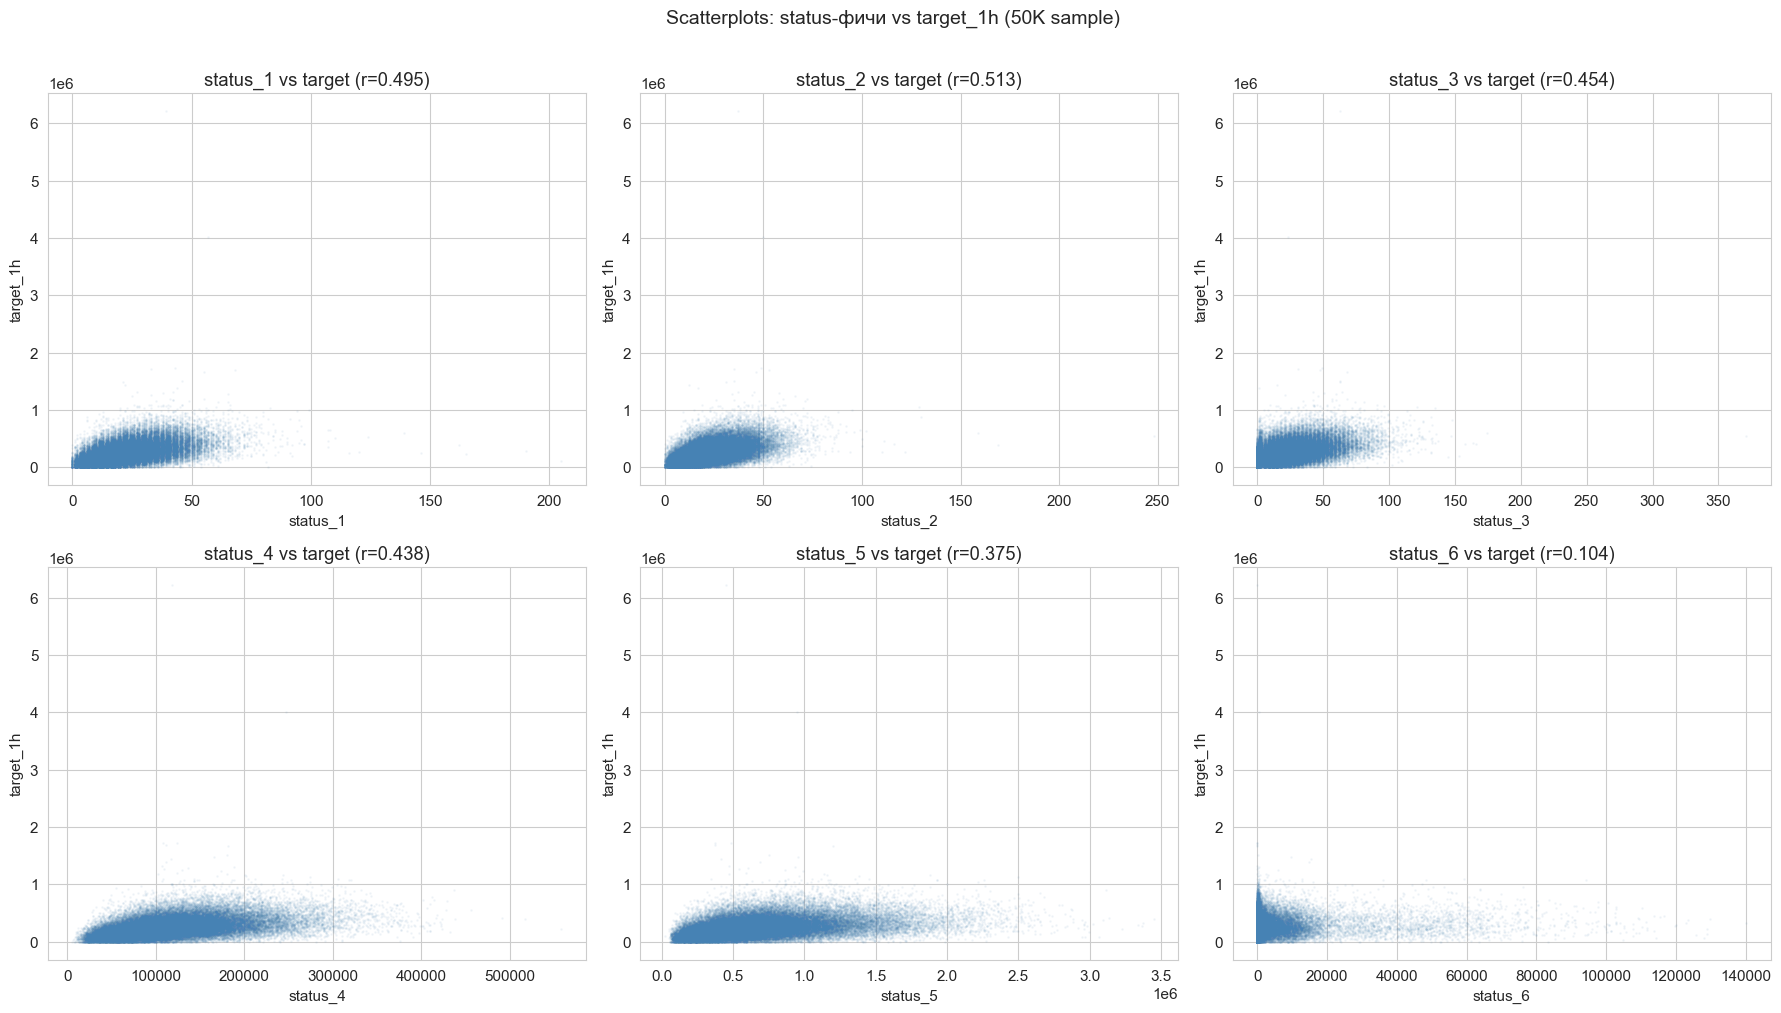

In [16]:
# Scatterplots: status vs target (sample for speed)
np.random.seed(42)
sample_idx = np.random.choice(len(train), 50000, replace=False)
sample = train.iloc[sample_idx]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(status_cols):
    ax = axes[i // 3, i % 3]
    ax.scatter(sample[col], sample['target_1h'], alpha=0.05, s=1, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('target_1h')
    r = sample[col].corr(sample['target_1h'])
    ax.set_title(f'{col} vs target (r={r:.3f})')

plt.suptitle('Scatterplots: status-фичи vs target_1h (50K sample)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<a id="8"></a>
## 8. Лаговые корреляции status → target

Ищем оптимальный лаг: через сколько времени status-фичи «превращаются» в отгрузку?

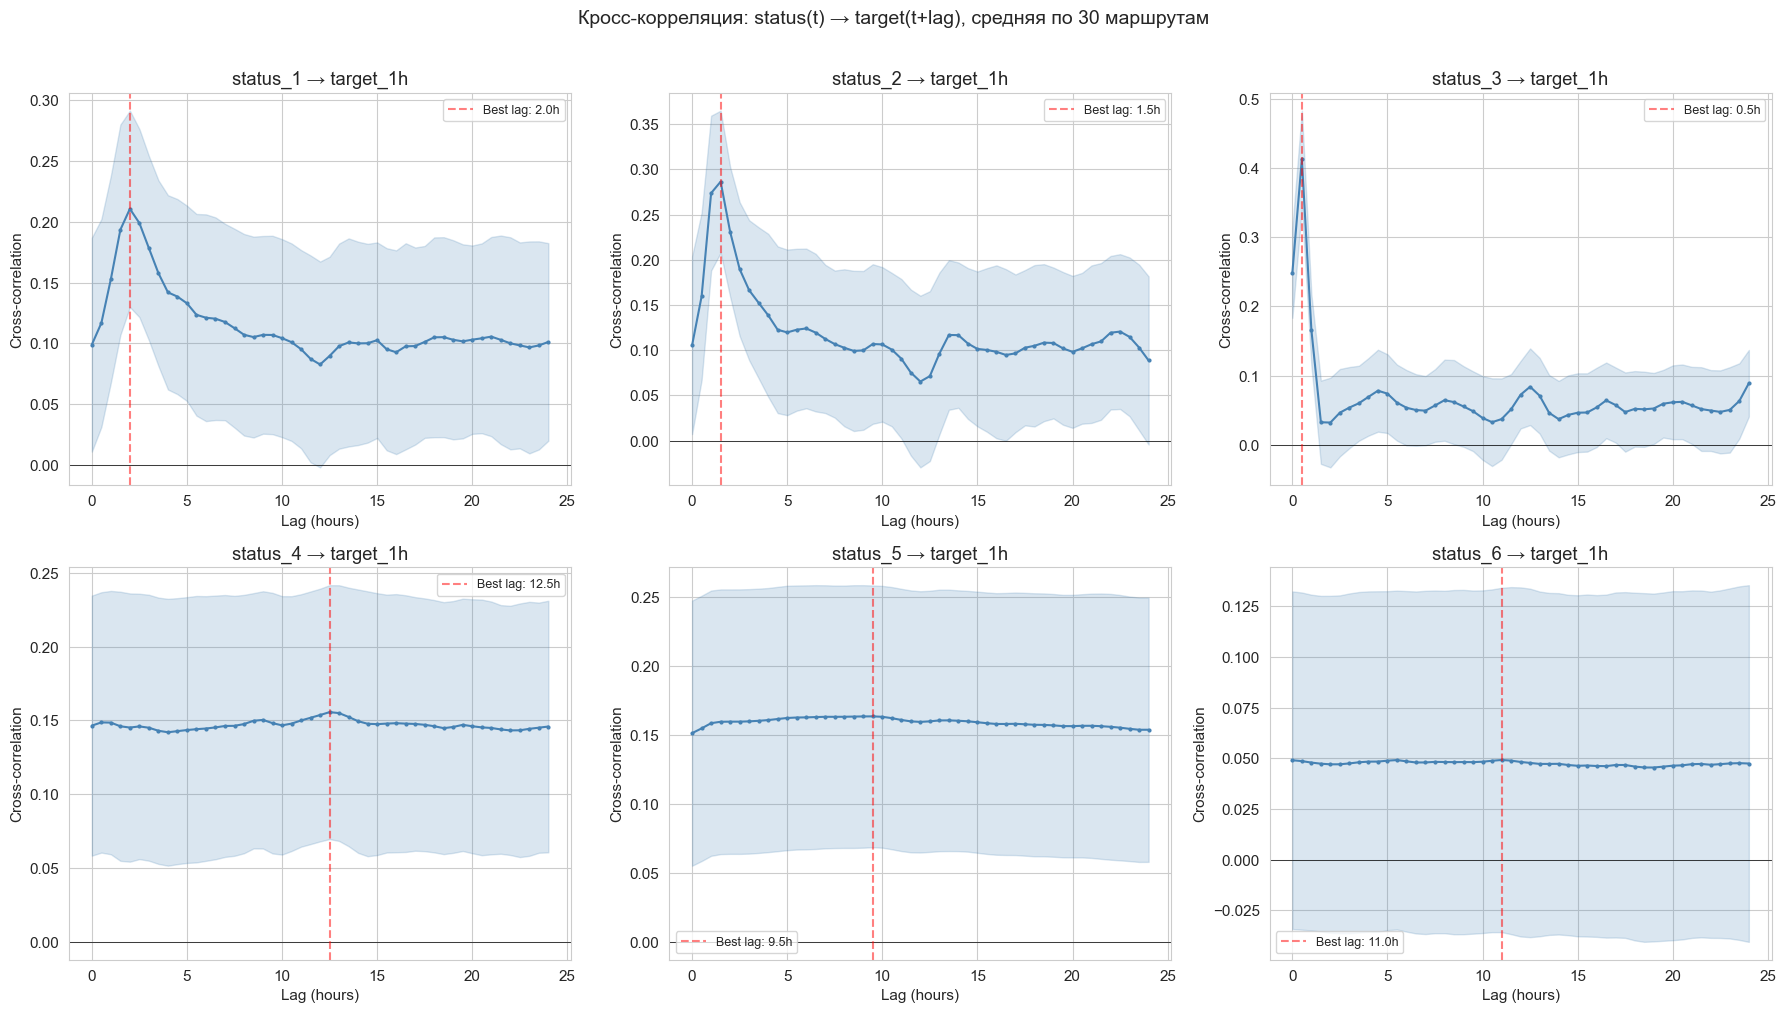

In [17]:
# Cross-correlation: status features → target at various lags
# Positive lag = status BEFORE target (predicting forward)
n_routes_sample = 30
np.random.seed(42)
routes_cc = np.random.choice(train.route_id.unique(), n_routes_sample, replace=False)
lags_to_test = list(range(0, 49))  # 0..48 steps = 0..24 hours

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for j, col in enumerate(status_cols):
    ax = axes[j // 3, j % 3]
    all_cc = np.zeros((n_routes_sample, len(lags_to_test)))

    for i, rid in enumerate(routes_cc):
        r = train[train.route_id == rid].sort_values('timestamp').reset_index(drop=True)
        for k, lag in enumerate(lags_to_test):
            if lag == 0:
                all_cc[i, k] = r[col].corr(r['target_1h'])
            else:
                all_cc[i, k] = r[col].corr(r['target_1h'].shift(-lag))

    mean_cc = np.nanmean(all_cc, axis=0)
    std_cc = np.nanstd(all_cc, axis=0)
    lag_hours = np.array(lags_to_test) * 0.5

    ax.plot(lag_hours, mean_cc, 'o-', markersize=2, color='steelblue')
    ax.fill_between(lag_hours, mean_cc - std_cc, mean_cc + std_cc, alpha=0.2, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5)

    best_lag = lags_to_test[np.argmax(np.abs(mean_cc))]
    ax.axvline(best_lag * 0.5, color='red', ls='--', alpha=0.5,
               label=f'Best lag: {best_lag * 0.5:.1f}h')

    ax.set_title(f'{col} → target_1h')
    ax.set_xlabel('Lag (hours)')
    ax.set_ylabel('Cross-correlation')
    ax.legend(fontsize=9)

plt.suptitle('Кросс-корреляция: status(t) → target(t+lag), средняя по 30 маршрутам', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<a id="9"></a>
## 9. Паттерны по дням: тепловые карты и недельные профили

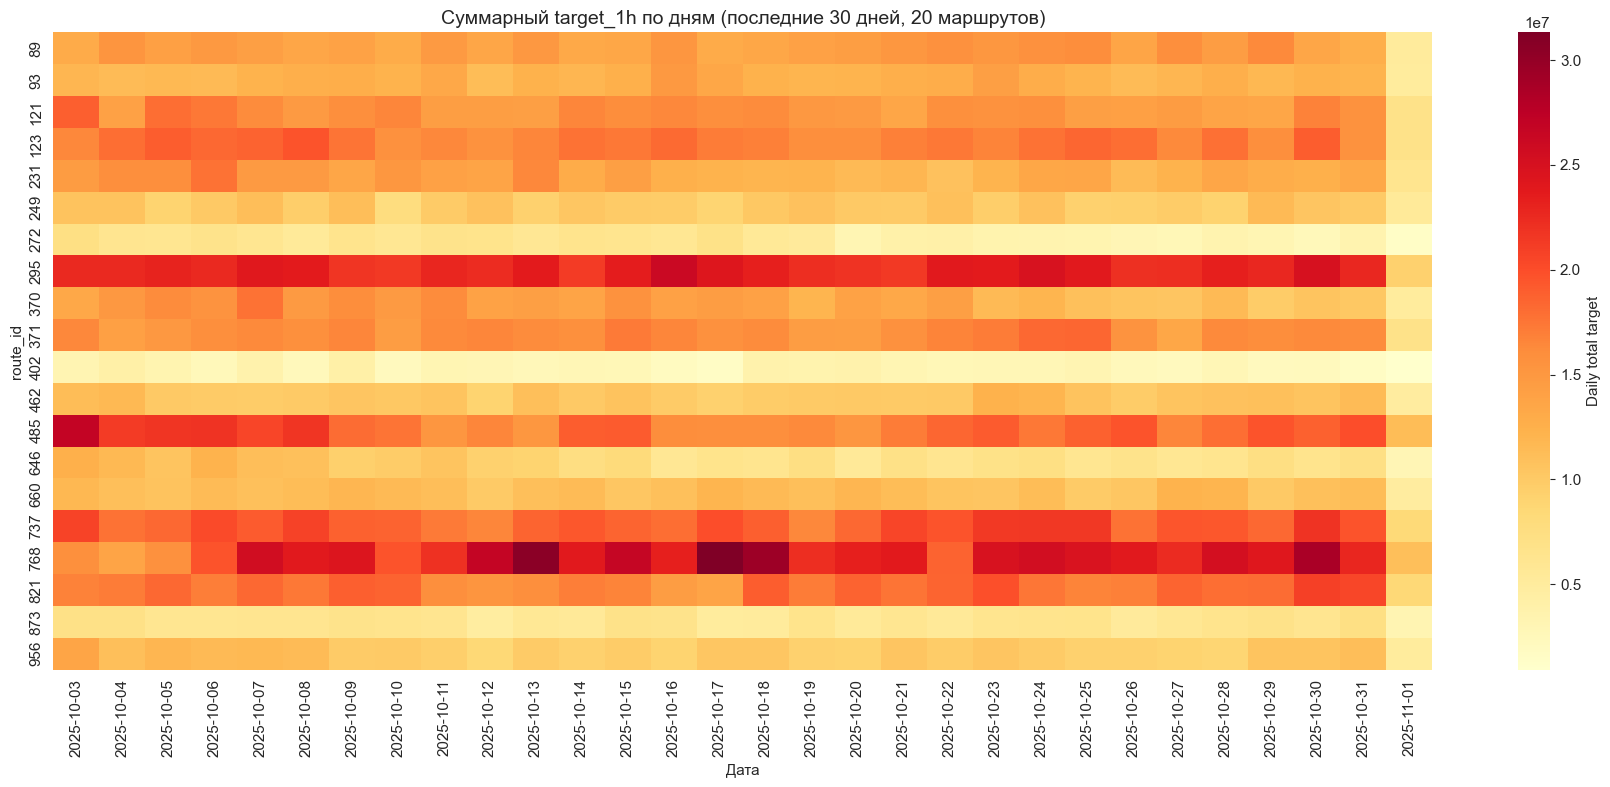

In [18]:
# Daily totals heatmap by route (sample routes)
train['date'] = train.timestamp.dt.date

# Pick 20 diverse routes
np.random.seed(42)
sample_20 = np.random.choice(train.route_id.unique(), 20, replace=False)
sub = train[train.route_id.isin(sample_20)]
daily = sub.groupby(['route_id', 'date'])['target_1h'].sum().unstack()

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(daily.iloc[:, -30:], cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Daily total target'})
ax.set_title('Суммарный target_1h по дням (последние 30 дней, 20 маршрутов)', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('route_id')
plt.tight_layout()
plt.show()

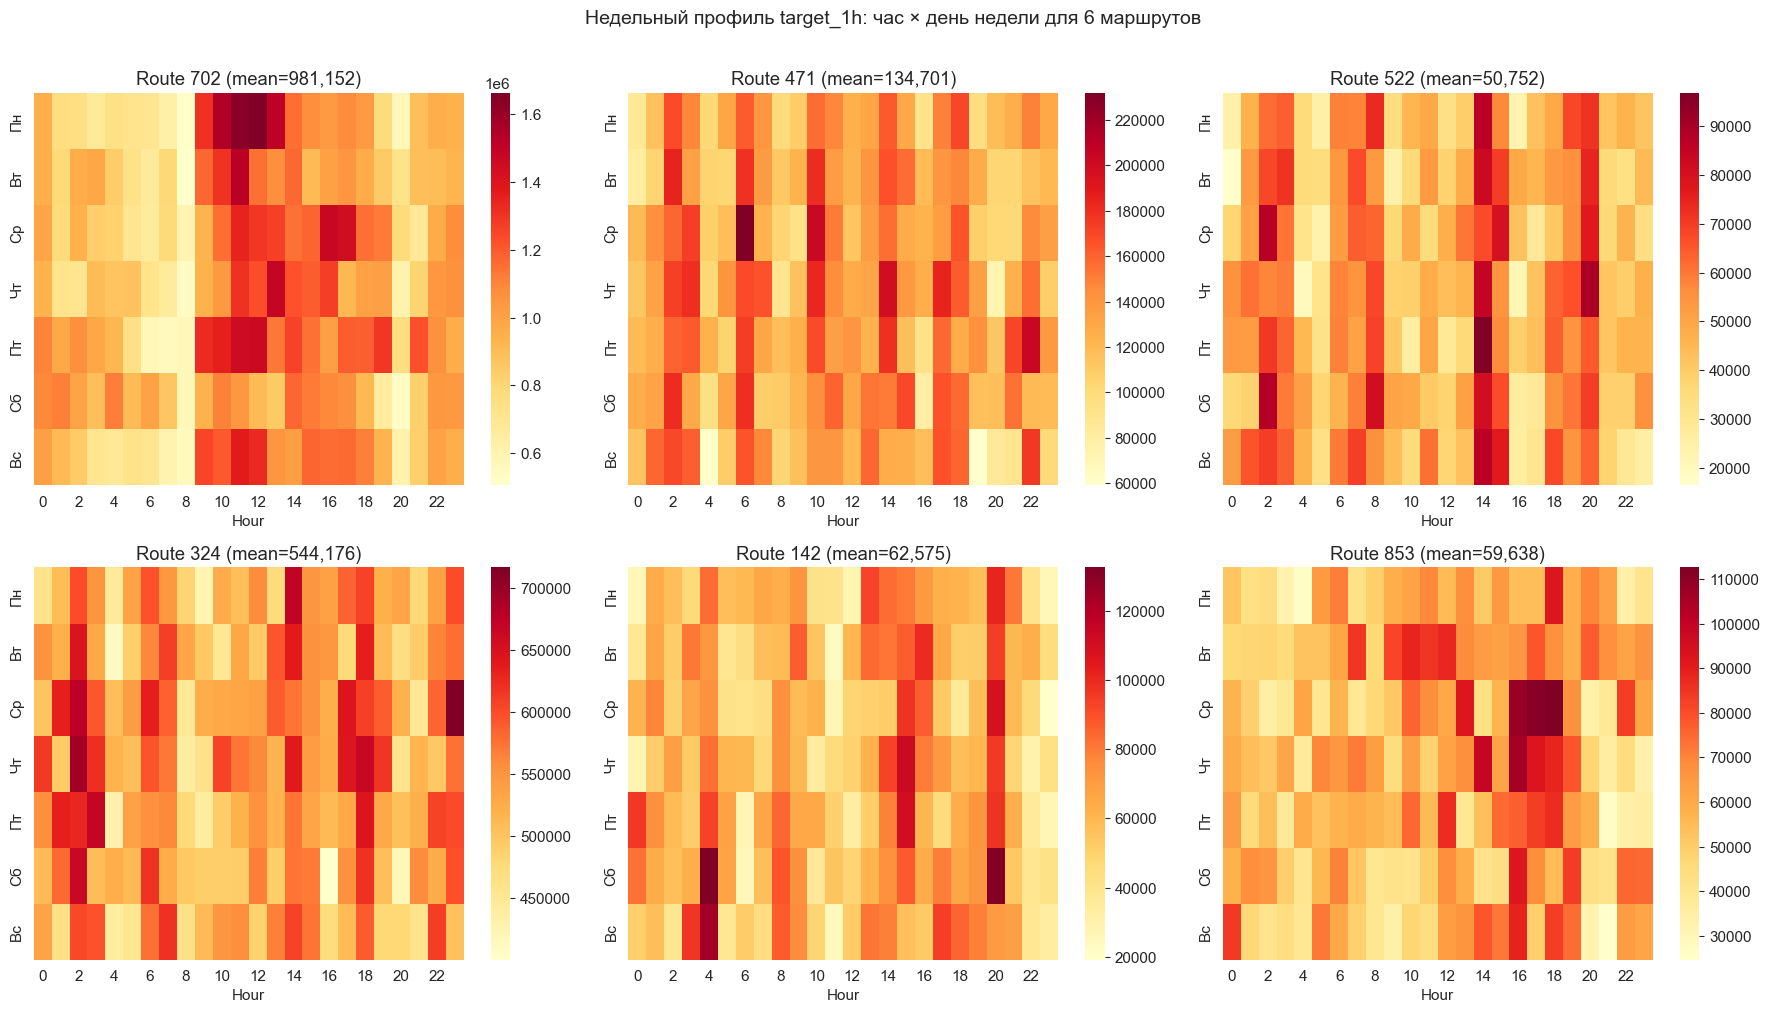

In [19]:
# Weekly profile for different routes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sample_6 = [702, 471, 522, 324, 142, 853]

for i, rid in enumerate(sample_6):
    ax = axes[i // 3, i % 3]
    r = train[train.route_id == rid]
    profile = r.groupby(['dow', 'hour'])['target_1h'].mean().unstack()
    sns.heatmap(profile, cmap='YlOrRd', ax=ax, cbar=True,
                yticklabels=dow_names, xticklabels=2)
    ax.set_title(f'Route {rid} (mean={r["target_1h"].mean():,.0f})')
    ax.set_xlabel('Hour')
    ax.set_ylabel('')

plt.suptitle('Недельный профиль target_1h: час × день недели для 6 маршрутов', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

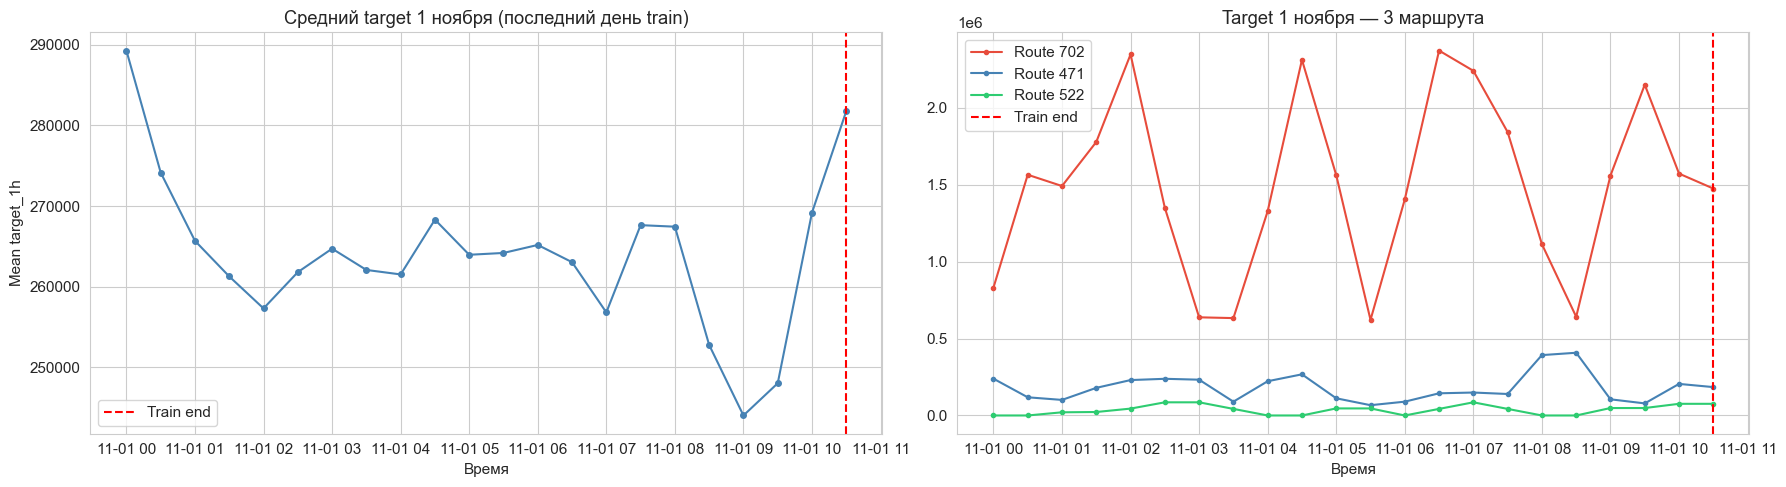

In [20]:
# Zoom into last day of train (Nov 1) — closest context for test
last_day = train[train.timestamp.dt.date == pd.Timestamp('2025-11-01').date()]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Aggregated across all routes
ts_agg = last_day.groupby('timestamp')['target_1h'].mean()
axes[0].plot(ts_agg.index, ts_agg.values, 'o-', color='steelblue', markersize=4)
axes[0].axvline(pd.Timestamp('2025-11-01 10:30:00'), color='red', ls='--', label='Train end')
axes[0].set_title('Средний target 1 ноября (последний день train)')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Mean target_1h')
axes[0].legend()

# For 3 sample routes
for rid, color in zip([702, 471, 522], ['#e74c3c', 'steelblue', '#2ecc71']):
    r = last_day[last_day.route_id == rid].sort_values('timestamp')
    axes[1].plot(r['timestamp'], r['target_1h'], 'o-', markersize=3, label=f'Route {rid}', color=color)
axes[1].axvline(pd.Timestamp('2025-11-01 10:30:00'), color='red', ls='--', label='Train end')
axes[1].set_title('Target 1 ноября — 3 маршрута')
axes[1].set_xlabel('Время')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="10"></a>
## 10. Бейзлайны

Оценим простые методы на валидации, имитирующей тест (последние 8 шагов → предсказание без status-фичей).

In [21]:
def wape_rbias(y_true, y_pred):
    wape = np.abs(y_pred - y_true).sum() / y_true.sum()
    rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
    return wape, rbias, wape + rbias

# Validation: last 8 timestamps of train (07:00–10:30, simulating 11:00–14:30)
val_start = '2025-11-01 07:00:00'
val_end = '2025-11-01 10:30:00'
val = train[(train.timestamp >= val_start) & (train.timestamp <= val_end)].copy()
train_part = train[train.timestamp < val_start].copy()
y_true = val['target_1h'].values

results = {}

# 1. Last known value (persistence)
last_known = train_part.sort_values('timestamp').groupby('route_id')['target_1h'].last()
pred1 = val['route_id'].map(last_known).values.clip(0)
results['Last value'] = wape_rbias(y_true, pred1)

# 2. Route mean
route_mean = train_part.groupby('route_id')['target_1h'].mean()
pred2 = val['route_id'].map(route_mean).values.clip(0)
results['Route mean'] = wape_rbias(y_true, pred2)

# 3. Route median
route_median = train_part.groupby('route_id')['target_1h'].median()
pred3 = val['route_id'].map(route_median).values.clip(0)
results['Route median'] = wape_rbias(y_true, pred3)

# 4. Route + hour mean
train_part['hour'] = train_part.timestamp.dt.hour
rh = train_part.groupby(['route_id', 'hour'])['target_1h'].mean()
val['hour'] = val.timestamp.dt.hour
pred4 = val.set_index(['route_id', 'hour']).index.map(lambda x: rh.get(x, np.nan))
pred4 = pd.Series(pred4).fillna(val['route_id'].map(route_mean)).values.clip(0)
results['Route+hour mean'] = wape_rbias(y_true, pred4)

# 5. Route + dow + hour mean
train_part['dow'] = train_part.timestamp.dt.dayofweek
rdh = train_part.groupby(['route_id', 'dow', 'hour'])['target_1h'].mean()
val['dow'] = val.timestamp.dt.dayofweek
pred5 = val.set_index(['route_id', 'dow', 'hour']).index.map(lambda x: rdh.get(x, np.nan))
pred5 = pd.Series(pred5).fillna(val['route_id'].map(route_mean)).values.clip(0)
results['Route+dow+hour mean'] = wape_rbias(y_true, pred5)

# 6. Rolling mean last 24h per route
last_24h = train_part[train_part.timestamp >= pd.Timestamp(val_start) - pd.Timedelta(hours=24)]
r24 = last_24h.groupby('route_id')['target_1h'].mean()
pred6 = val['route_id'].map(r24).fillna(val['route_id'].map(route_mean)).values.clip(0)
results['Rolling mean 24h'] = wape_rbias(y_true, pred6)

# 7. Rolling mean last 4h (same window as test)
last_4h = train_part[train_part.timestamp >= pd.Timestamp(val_start) - pd.Timedelta(hours=4)]
r4 = last_4h.groupby('route_id')['target_1h'].mean()
pred7 = val['route_id'].map(r4).fillna(val['route_id'].map(route_mean)).values.clip(0)
results['Rolling mean 4h'] = wape_rbias(y_true, pred7)

# Display
print(f'{"Baseline":<25} {"WAPE":>8} {"RBias":>8} {"Total":>8}')
print('-' * 53)
for name, (w, r, t) in sorted(results.items(), key=lambda x: x[1][2]):
    print(f'{name:<25} {w:>8.4f} {r:>8.4f} {t:>8.4f}')

Baseline                      WAPE    RBias    Total
-----------------------------------------------------
Route mean                  0.3807   0.0011   0.3818
Rolling mean 24h            0.3666   0.0304   0.3970
Route+hour mean             0.3713   0.0294   0.4007
Rolling mean 4h             0.3898   0.0121   0.4019
Route+dow+hour mean         0.3781   0.0311   0.4092
Route median                0.3796   0.0480   0.4276
Last value                  0.5079   0.0080   0.5159


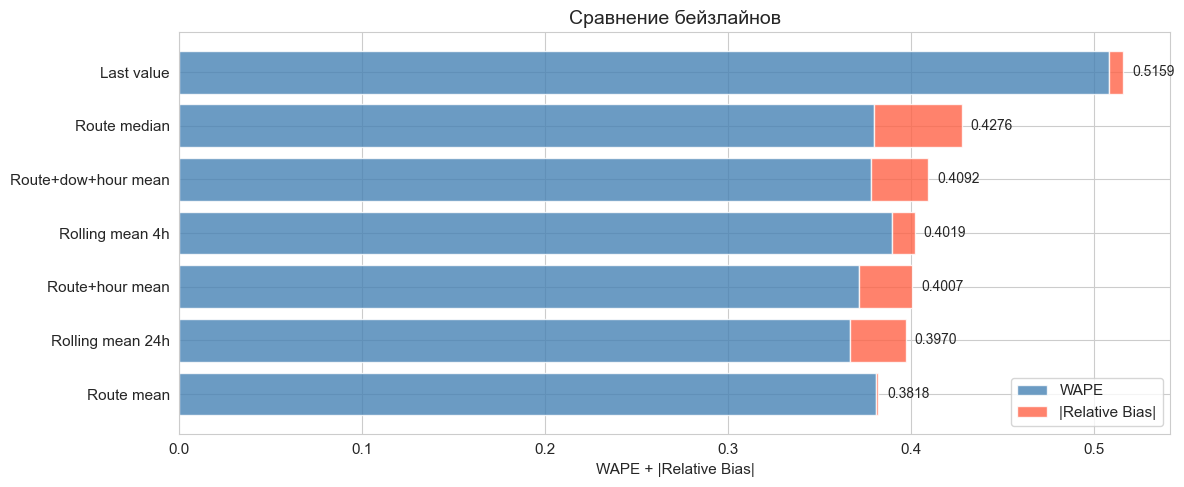

In [22]:
# Визуализация бейзлайнов
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
totals = [results[n][2] for n in names]
wapes = [results[n][0] for n in names]
rbiases = [results[n][1] for n in names]

# Sort by total
order = np.argsort(totals)
names = [names[i] for i in order]
wapes = [wapes[i] for i in order]
rbiases = [rbiases[i] for i in order]

y_pos = np.arange(len(names))
ax.barh(y_pos, wapes, color='steelblue', alpha=0.8, label='WAPE')
ax.barh(y_pos, rbiases, left=wapes, color='tomato', alpha=0.8, label='|Relative Bias|')

for i, (w, r) in enumerate(zip(wapes, rbiases)):
    ax.text(w + r + 0.005, i, f'{w+r:.4f}', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.set_xlabel('WAPE + |Relative Bias|')
ax.set_title('Сравнение бейзлайнов', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

<a id="11"></a>
## 11. Выводы

### Структура задачи
- **Train**: 1000 маршрутов × 4630 шагов (30 мин), ~96.5 дней (28 июля — 1 ноября 10:30)
- **Test**: 1000 маршрутов × 8 шагов (1 ноября 11:00–14:30, суббота)
- Идеальная сетка — нет пропусков, все маршруты из теста есть в train

### Ключевая ловушка: status-фичи отсутствуют в test
- `status_1-6` — самые коррелированные с target (до 0.51), но в тесте их НЕТ
- Модель должна работать без них → использовать только лаговые агрегаты до момента обрезки

### Характер данных
- Таргет **очень шумный** (CV ≈ 0.49 внутри группы route+dow+hour)
- **Масштаб маршрутов** различается в 20x (50K–981K)
- Сезонность (часовая, недельная) **очень слабая** (<1% дисперсии)
- Автокорреляция: lag-1 (30 мин) ≈ 0.42, затем резкое падение

### Бейзлайн для битья
- **Route mean ≈ 0.38** — лучший простой бейзлайн
- Более гранулярные группировки (route+hour, route+dow+hour) хуже из-за переобучения
- Rolling mean 24h/4h также не лучше простого route mean

### Рекомендации для моделирования
1. **Direct multi-step** (8 моделей/горизонтов) — надёжнее recursive
2. **Главные фичи**: лаги target (до точки обрезки), rolling-агрегаты target и status, route-level статистики
3. **MAE loss** (ближе к WAPE)
4. **Калибровка RBias** после обучения — бесплатное улучшение метрики
5. **LightGBM / CatBoost** — основная ставка